#### 1. Importaciones

In [1]:
import os
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def load_data(folder, filename):
    route = os.path.join(folder, filename)
    data = pd.read_csv(route)
    return data


In [3]:
# Generales:
folder = "./datasets"
file_name_training = "gold_recovery_train.csv"

##### 2. Carga de datos

In [4]:
training_data = load_data(folder, file_name_training)

#### 3. Explorar datos (EDA)

##### 3.1. Exploracion inicial

In [5]:
training_data.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [6]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  str    
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64
 9   final.

##### 3.2. Conclusiones del EDA inicial

- Se observan muchas variables innecesarias. Se recomienda filtrar el dataframe para que solo contenga lo relacionado al oro.
- Los datos presentan valores ausentes o nulos. 
- Se recomienda revisar si hay datos duplicados.
- Lo mejor es eliinar esas filas con valores ausentes. Hay suficientes datos para entrenar el modelo.
- Para el modelo lineal se recomienda usar un scaler para que los datos estén en el mismo orden de magnitud.

##### 3.3. Exploración orientada de los datos 
Explorar los datos exclusivos para el calculo de los recoveries: 
1. rougher.output.recovery
2. final.output.recovery

In [7]:
# Crear un nuevo dataframe que contenga solo las columnas relacionadas con el Oro y los target de recuperacion (rougher.output.recovery y final.output.recovery)
columnas_de_interes = []
for column in training_data.columns:
    if "_au" in column:
        columnas_de_interes.append(column) 
    elif column == "rougher.output.recovery":
        columnas_de_interes.append(column)
    elif column == "final.output.recovery":
        columnas_de_interes.append(column)

au_df = training_data[columnas_de_interes]

In [8]:
# Explorar este nuevo dataframe
au_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_au                         16789 non-null  float64
 1   final.output.recovery                               15339 non-null  float64
 2   final.output.tail_au                                16794 non-null  float64
 3   primary_cleaner.output.concentrate_au               16778 non-null  float64
 4   primary_cleaner.output.tail_au                      16777 non-null  float64
 5   rougher.calculation.sulfate_to_au_concentrate       16833 non-null  float64
 6   rougher.calculation.floatbank10_sulfate_to_au_feed  16833 non-null  float64
 7   rougher.calculation.floatbank11_sulfate_to_au_feed  16833 non-null  float64
 8   rougher.input.feed_au                               16777 non-null  float64
 9   roughe

In [9]:
# Explorar la forma de los datos nulos o ausentes
nulos = au_df[au_df["rougher.output.tail_au"].isna()]
nulos.head(5)

,final.output.concentrate_au,final.output.recovery,final.output.tail_au,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_au,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.input.feed_au,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_au,secondary_cleaner.output.tail_au
99,0.0,NaN,0.0,0.0,0.0,652.624634,-1607.685064,-276.558327,0.0,0.0,NaN,NaN,0.0
100,0.0,NaN,0.0,0.0,0.0,-1113.249700,-5862.022260,738.069870,0.0,0.0,NaN,NaN,0.0
101,0.0,NaN,0.0,0.0,0.0,-5026.304089,-7072.017271,-10516.041812,0.0,0.0,NaN,NaN,0.0
102,0.0,NaN,0.0,0.0,0.0,-13348.010125,-7812.535185,7804.366138,0.0,0.0,NaN,NaN,0.0
103,0.0,NaN,0.0,0.0,0.0,-29798.326724,-6995.433653,-5116.644534,0.0,0.0,NaN,NaN,0.0


In [10]:
# Verificar si hay filas duplicadas
cantidad_de_duplicados = au_df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {cantidad_de_duplicados}")

Cantidad de filas duplicadas: 17


La exploración de datos ausentes o nulos y la de datos duplicados indicó:

- Hay datos duplicados.
- Es mejor eliminar las filas que contengan algún dato nulo en alguna de sus columnas.

In [11]:
# Eliminar datos ausentes o nulos
au_df = au_df.dropna()
au_df.info() # Asegurar que no hay datos nulos.

<class 'pandas.DataFrame'>
Index: 14148 entries, 0 to 16859
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_au                         14148 non-null  float64
 1   final.output.recovery                               14148 non-null  float64
 2   final.output.tail_au                                14148 non-null  float64
 3   primary_cleaner.output.concentrate_au               14148 non-null  float64
 4   primary_cleaner.output.tail_au                      14148 non-null  float64
 5   rougher.calculation.sulfate_to_au_concentrate       14148 non-null  float64
 6   rougher.calculation.floatbank10_sulfate_to_au_feed  14148 non-null  float64
 7   rougher.calculation.floatbank11_sulfate_to_au_feed  14148 non-null  float64
 8   rougher.input.feed_au                               14148 non-null  float64
 9   rougher.out

In [12]:
# Eliminar filas duplicadas
au_df = au_df.drop_duplicates()
au_df.info() # Asegurar que no hay filas duplicadas.

<class 'pandas.DataFrame'>
Index: 14148 entries, 0 to 16859
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_au                         14148 non-null  float64
 1   final.output.recovery                               14148 non-null  float64
 2   final.output.tail_au                                14148 non-null  float64
 3   primary_cleaner.output.concentrate_au               14148 non-null  float64
 4   primary_cleaner.output.tail_au                      14148 non-null  float64
 5   rougher.calculation.sulfate_to_au_concentrate       14148 non-null  float64
 6   rougher.calculation.floatbank10_sulfate_to_au_feed  14148 non-null  float64
 7   rougher.calculation.floatbank11_sulfate_to_au_feed  14148 non-null  float64
 8   rougher.input.feed_au                               14148 non-null  float64
 9   rougher.out

Conclusión del filtrado de datos:
- Las filas duplicadas eran las mismas que las filas con datos nulos.

Calcular los datos de la recuperación teórica de oro de acuerdo a la fórmula. Este cálculo se debe incluir como fila en los datos

Recuperacion = (C*(F-T))/(F*(C-T))

Este cálculo teórico permite obtener las 2 recuperaciones del proceso:

1. La recuperación del concentrado rougher (corresponde al 3 en la figura)
En este caso las variables significan lo siguiente:

- C -> rougher.ouput.concentrate_au
- F -> rougher.input.feed_au
- T -> rougher.output.tail_au

2. La recuperación del concentrado final (corresponde al 8 en la figura)

- C -> final.output.concentrate_au
- F -> rougher.input.feed_au
- T -> final.output.tail_au

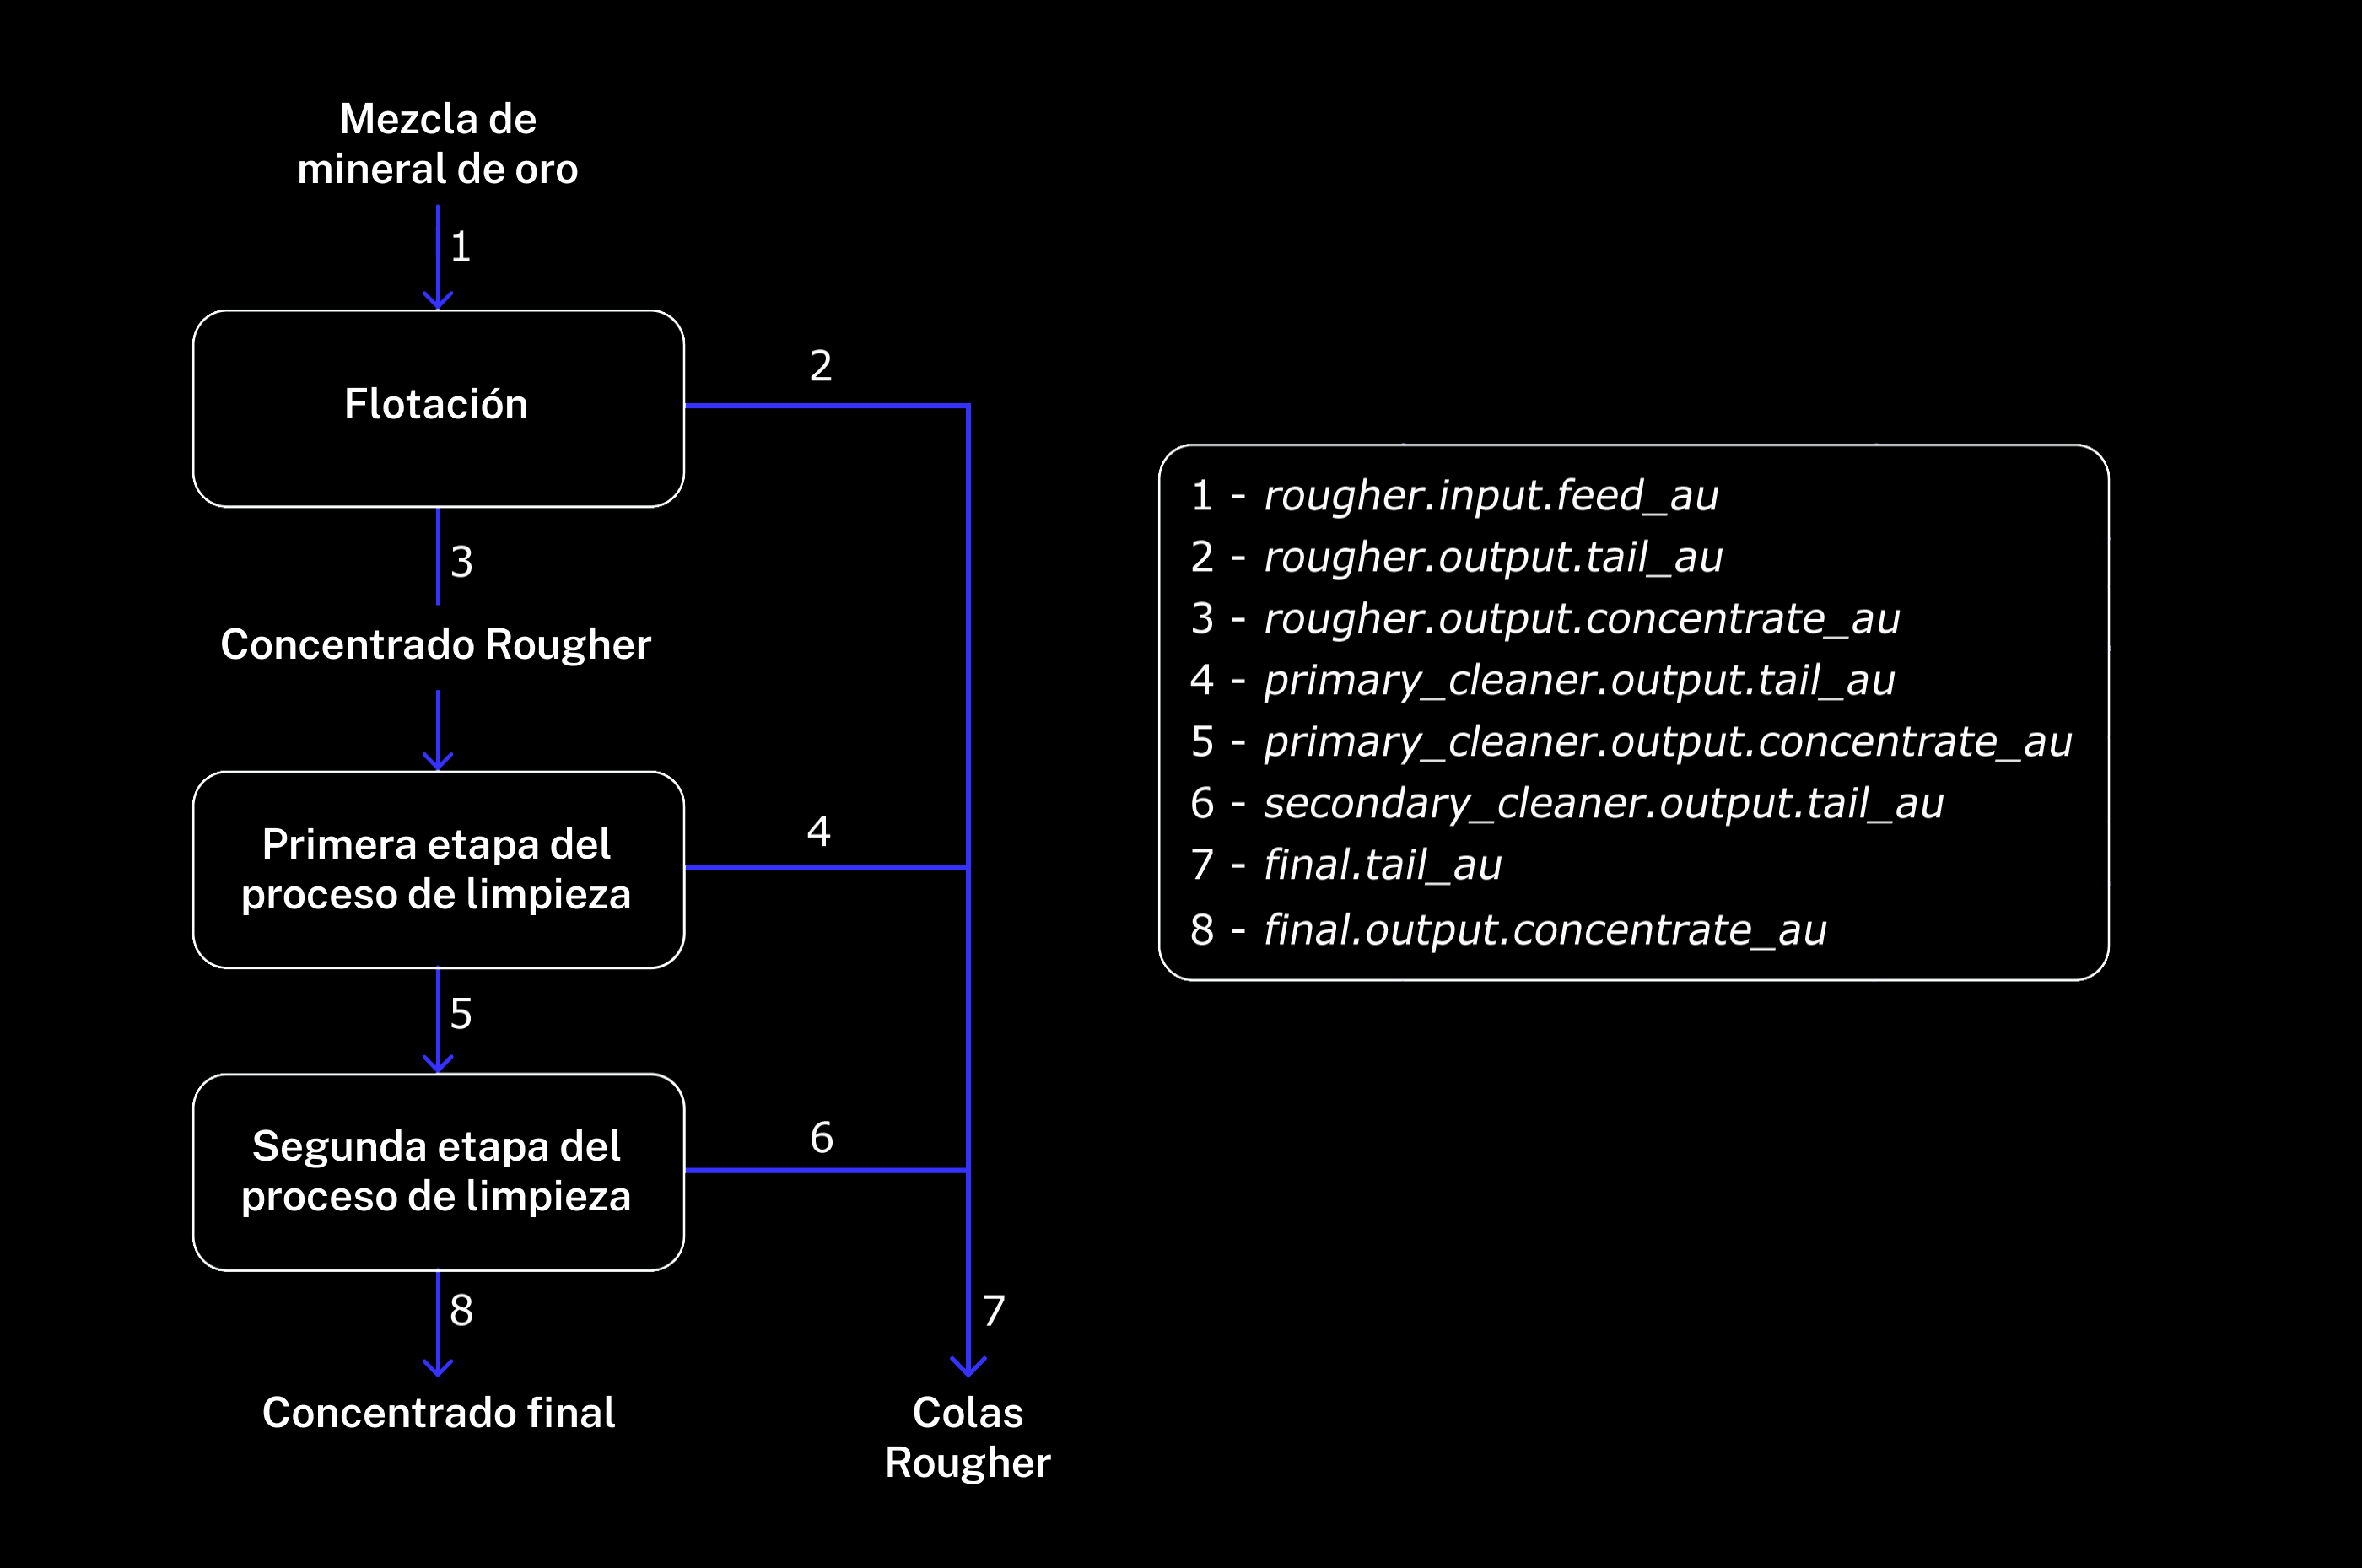

#### 4. Calculo de recoveries


##### 4.1. rougher.output.recovery

In [13]:
# Crear un dataframe exclusivo para este calculo cuyas columnas se llamen con en la formula de recuperacion: C, F, T y recovery
df_rougher = au_df[["rougher.output.concentrate_au", "rougher.input.feed_au", "rougher.output.tail_au", "rougher.output.recovery"]].copy()
df_rougher = df_rougher.rename(columns={"rougher.output.concentrate_au": "C", "rougher.input.feed_au": "F", "rougher.output.tail_au": "T", "rougher.output.recovery": "recovery"})

# Eliminar los valores donde C, F o T sean iguales a 0 para evitar divisiones por cero
df_rougher = df_rougher.drop(df_rougher[df_rougher["C"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["F"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["T"]==0].index)

# Calcular la recuperación
df_rougher["recovery"] = (df_rougher["C"] * (df_rougher["F"] - df_rougher["T"])) / (df_rougher["F"] * (df_rougher["C"] - df_rougher["T"]))*100
df_rougher.info()

<class 'pandas.DataFrame'>
Index: 13851 entries, 0 to 16859
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   C         13851 non-null  float64
 1   F         13851 non-null  float64
 2   T         13851 non-null  float64
 3   recovery  13851 non-null  float64
dtypes: float64(4)
memory usage: 541.1 KB


In [14]:
df_rougher["recovery"].head()

0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
Name: recovery, dtype: float64

In [15]:
# Contrastar el calculado contra los valores reales para confirmar que se tienen bien definidos los features y el target
training_data["rougher.output.recovery"].head()

0    87.107763
1    86.843261
2    86.842308
3    87.226430
4    86.688794
Name: rougher.output.recovery, dtype: float64

In [16]:
# Se aprecia que el cálculo fue hecho correctamente. Ahora se repetite el mismo procedimiento para calcular el final.output.recovery

##### 4.2. final.output.recovery

In [17]:
# Crear un dataframe exclusivo para este calculo cuyas columnas se llamen con en la formula de recuperacion: C, F, T y recovery
df_final = au_df[["final.output.concentrate_au","rougher.input.feed_au","final.output.tail_au"]].copy()
df_final = df_final.rename(columns={"final.output.concentrate_au": "C", "rougher.input.feed_au": "F", "final.output.tail_au": "T"})

# Eliminar los valores donde C, F o T sean iguales a 0 para evitar divisiones por cero
df_final = df_final.drop(df_final[df_final["C"]==0].index)
df_final = df_final.drop(df_final[df_final["F"]==0].index)
df_final = df_final.drop(df_final[df_final["T"]==0].index)

# Calcular la recuperación
df_final["recovery"] = (df_final["C"] * (df_final["F"] - df_final["T"])) / (df_final["F"] * (df_final["C"] - df_final["T"]))*100
df_final.info()

<class 'pandas.DataFrame'>
Index: 14015 entries, 0 to 16859
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   C         14015 non-null  float64
 1   F         14015 non-null  float64
 2   T         14015 non-null  float64
 3   recovery  14015 non-null  float64
dtypes: float64(4)
memory usage: 547.5 KB


In [18]:
df_final["recovery"].head()

0    70.541216
1    69.266198
2    68.116445
3    68.347543
4    66.927016
Name: recovery, dtype: float64

In [19]:
# Contrastar el calculado contra los valores reales para confirmar que se tienen bien definidos los features y el target
training_data["final.output.recovery"].head()

0    70.541216
1    69.266198
2    68.116445
3    68.347543
4    66.927016
Name: final.output.recovery, dtype: float64

##### 4.3. Conclusiones
- Se definieron correctamente los features y el target para ambos casos de recuperación (rougher.output.recovery y final.output.recovery).
- Se observó que los recoveries calculados coinciden con los recoveries de la tabla. Con esta información se procederá a entrenar los modelos para cambos casos.


#### 5. Entramiento de modelos
#### 5.1. Definir features, target y diccionario de resultados


In [20]:
# Datos para la primera recuperación (rougher)
features_rougher = df_rougher[["C", "F", "T"]]
target_rougher = df_rougher["recovery"]

# Datos para la recuperación final (final)
features_final = df_final[["C", "F", "T"]]
target_final = df_final["recovery"]

# Preparar diccionario para guardar los datos, resultados y los modelos
resultados = {
    
    "recovery_rougher": {  
        "data": {
            "target": target_rougher,
            "features": features_rougher,
        },
        
        "Modelo lineal": {
            "r2_score": None,
            "mse": None,
            "recovery_predicted": None,
            "model": None,},
        
        "Random Forest": {
            "r2_score": None,
            "mse": None,
            "recovery_predicted": None,
            "model": None,
        }
    },
    "recovery_final": {  
        
        "data": {
            "target": target_final,
            "features": features_final,
        },
        
        "Modelo lineal": {
            "r2_score": None,
            "mse": None,
            "recovery_predicted": None,
            "model": None,},
        
        "Random Forest": {
            "r2_score": None,
            "mse": None,
            "recovery_predicted": None,
            "model": None,
        }
    },
}

##### 5.2. Modelos para el primer recovery (rougher):

#### 5.2.1. Modelo lineal

In [21]:
model = LinearRegression()
model.fit(features_rougher, target_rougher)
recovery_predicted = model.predict(features_rougher)
model_score = model.score(features_rougher, target_rougher)
print(f"R^2 score del modelo lineal: {model_score:.4f}")
print(f"mean_squared_error del modelo lineal: {mean_squared_error(target_rougher, recovery_predicted):.4f}")

# Guardar los resultados y el modelo en el diccionario
resultados["recovery_rougher"]["Modelo lineal"]["r2_score"] = model_score
resultados["recovery_rougher"]["Modelo lineal"]["mse"] = mean_squared_error(target_rougher, recovery_predicted)
resultados["recovery_rougher"]["Modelo lineal"]["recovery_predicted"] = recovery_predicted
resultados["recovery_rougher"]["Modelo lineal"]["model"] = model


R^2 score del modelo lineal: 0.8872
mean_squared_error del modelo lineal: 7.2568


#### 5.2.2. Random Forest

In [ ]:
best_r2_score = 0
best_estimator = 0
best_depth = 0

n_estimators = [10, 50, 100, 200, 250, 300]
max_depths = [2, 4, 6, 8, 10]

for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        model.fit(features_rougher, target_rougher)
        recovery_predicted = model.predict(features_rougher)
        score = model.score(features_rougher, target_rougher)
        if score > best_r2_score:
            best_r2_score = score
            best_estimator = n
            best_depth = d
            
print(f"Mejor R^2 score del modelo Random Forest: {best_r2_score} con n_estimators={best_estimator} y max_depth={best_depth}")    


Mejor R^2 score del modelo Random Forest: 0.9952809656203196 con n_estimators=300 y max_depth=10


In [23]:
# Usar los mejores hiperparámetros para entrenar al modelo final de random forest y guardar los resultados en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features_rougher, target_rougher)
recovery_predicted = model.predict(features_rougher)
score = model.score(features_rougher, target_rougher)
mse = mean_squared_error(target_rougher, recovery_predicted) 

resultados["recovery_rougher"]["Random Forest"]["r2_score"] = score
resultados["recovery_rougher"]["Random Forest"]["mse"] = mse
resultados["recovery_rougher"]["Random Forest"]["recovery_predicted"] = recovery_predicted
resultados["recovery_rougher"]["Random Forest"]["model"] = model

print(f"R^2 score del modelo Random Forest: {score:.4f}")
print(f"mean_squared_error del modelo Random Forest: {mse:.4f}")

R^2 score del modelo Random Forest: 0.9953
mean_squared_error del modelo Random Forest: 0.3036


#### 5.3. Modelos del segundo recovery (final):


#### 5.3.1. Modelo lineal

In [24]:
model = LinearRegression()
model.fit(features_final, target_final)
recovery_predicted = model.predict(features_final)
model_score = model.score(features_final, target_final)
print(f"R^2 score del modelo lineal: {model_score:.4f}")
print(f"mean_squared_error del modelo lineal: {mean_squared_error(target_final, recovery_predicted):.4f}")

# Guardar los resultados y el modelo en el diccionario
resultados["recovery_final"]["Modelo lineal"]["r2_score"] = model_score
resultados["recovery_final"]["Modelo lineal"]["mse"] = mean_squared_error(target_final, recovery_predicted)
resultados["recovery_final"]["Modelo lineal"]["recovery_predicted"] = recovery_predicted
resultados["recovery_final"]["Modelo lineal"]["model"] = model

R^2 score del modelo lineal: 0.8910
mean_squared_error del modelo lineal: 9.0093


#### 5.3.2. Random Forest

In [26]:
best_r2_score = 0
best_estimator = 0
best_depth = 0

n_estimators = [10, 50, 100, 200, 250, 300]
max_depths = [2, 4, 6, 8, 10]

for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        model.fit(features_final, target_final)
        recovery_predicted = model.predict(features_final)
        score = model.score(features_final, target_final)
        if score > best_r2_score:
            best_r2_score = score
            best_estimator = n
            best_depth = d
            
print(f"Mejor R^2 score del modelo Random Forest: {best_r2_score} con n_estimators={best_estimator} y max_depth={best_depth}") 

Mejor R^2 score del modelo Random Forest: 0.9933595376678266 con n_estimators=100 y max_depth=10


In [27]:
# Usar los mejores hiperparámetros para entrenar al modelo final de random forest y guardar los resultados en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features_final, target_final)
recovery_predicted = model.predict(features_final)
score = model.score(features_final, target_final)
mse = mean_squared_error(target_final, recovery_predicted) 

resultados["recovery_final"]["Random Forest"]["r2_score"] = score
resultados["recovery_final"]["Random Forest"]["mse"] = mse
resultados["recovery_final"]["Random Forest"]["recovery_predicted"] = recovery_predicted
resultados["recovery_final"]["Random Forest"]["model"] = model

print(f"R^2 score del modelo Random Forest: {score:.4f}")
print(f"mean_squared_error del modelo Random Forest: {mse:.4f}")

R^2 score del modelo Random Forest: 0.9934
mean_squared_error del modelo Random Forest: 0.5490


In [28]:
#### 6. Función para calcular el sMAPE (error medio absoluto porcentual absoluto)

def smape(y_true, y_pred):
    n = len(y_true)
    smape_value = (1/n) * sum(2* abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))) *100
    return smape_value

In [33]:
recovery_rougher = resultados["recovery_rougher"]["Random Forest"]["recovery_predicted"]
recovery_final = resultados["recovery_final"]["Random Forest"]["recovery_predicted"]
sMAPE_final = 0.25 * smape(target_rougher, recovery_rougher) + 0.75 * smape(target_final, recovery_final)
print(f"sMAPE final: {sMAPE_final:.4f}%")

sMAPE final: 0.6254%


In [ ]:
### Con los modelos entrenados y teniendo tan buenos resltados

0.4245236019296417

0.6923627059968093